In [4]:
import pandas as pd
import seaborn as sns
import re
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch
import copy

def split_patches(patches, n, group_size):
    patches_groups = [patches[i * group_size:(i + 1) * group_size] for i in range(n)]    
    baseline_group = patches_groups[0]
    
    return (patches_groups, baseline_group)

def create_speedup_message(patches_groups, baseline_group):
    messages = []
    for pid, p in enumerate(baseline_group):
        baseline_height = baseline_group[pid].get_height()
        message = []
        for group in patches_groups[1:]:
            if group[pid].get_height() > 0:
                speedup = baseline_height / group[pid].get_height()
                message.append(f'{speedup:.1f}x')
        messages.append("/".join(message))
    return messages

# Load the csv files for NES and Apache Flink
df = pd.read_csv("results_nebulastream.csv")

df['system'] = 'NebulaStream'

# Create directory if it doesn't exist
output_dir = 'system_comparison'
os.makedirs(output_dir, exist_ok=True)

# Extract synopsis type and variant from query_name
df["synopsis_type"] = df["query_name"].str.split("_").str[0]
df["query_variant"] = df["query_name"].str.split("_", n=1).str[1]

df

,dataset,statistic_type,statistic_config,build_window_size_sec,bytesPerSecond,query_name,time,tuplesPerSecond,tuplesPerSecond_listener,executionMode,numberOfWorkerThreads,buffersInGlobalBufferManager,joinStrategy,bufferSizeInBytes,pageSize,enableLatency,issue,system,synopsis_type,query_variant
0,ClusterMonitoring,Reservoir,100,1,9.962656e+06,ClusterMonitoring_ReservoirBuild_100_1sec,153.348863,121611.967759,NaN,COMPILER,1,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
1,ClusterMonitoring,Reservoir,100,1,9.722263e+06,ClusterMonitoring_ReservoirBuild_100_1sec,157.140574,118677.541897,NaN,COMPILER,1,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
2,ClusterMonitoring,Reservoir,100,1,9.483070e+06,ClusterMonitoring_ReservoirBuild_100_1sec,161.104160,115757.761590,NaN,COMPILER,1,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
3,ClusterMonitoring,Reservoir,100,1,9.569292e+06,ClusterMonitoring_ReservoirBuild_100_1sec,159.652569,116810.253390,NaN,COMPILER,4,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
4,ClusterMonitoring,Reservoir,100,1,9.268268e+06,ClusterMonitoring_ReservoirBuild_100_1sec,164.837911,113135.727700,NaN,COMPILER,4,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,ReservoirBuild_100_1sec
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,ClusterMonitoring,CountMin,"(1, 10000, uint64)",1,7.936144e+06,ClusterMonitoring_CountMinBuild_1_10000_uint64...,192.506844,96874.774127,NaN,COMPILER,4,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,CountMinBuild_1_10000_uint64_1sec
68,ClusterMonitoring,CountMin,"(1, 10000, uint64)",1,8.439146e+06,ClusterMonitoring_CountMinBuild_1_10000_uint64...,181.032769,103014.814039,NaN,COMPILER,4,20000,HASH_JOIN,1048576,8192,False,ok,NebulaStream,ClusterMonitoring,CountMinBuild_1_10000_uint64_1sec
69,ClusterMonitoring,CountMin,"(1, 10000, uint64)",1,NaN,ClusterMonitoring_CountMinBuild_1_10000_uint64...,NaN,NaN,NaN,COMPILER,16,20000,HASH_JOIN,1048576,8192,False,crashed (SIGABRT),NebulaStream,ClusterMonitoring,CountMinBuild_1_10000_uint64_1sec
70,ClusterMonitoring,CountMin,"(1, 10000, uint64)",1,NaN,ClusterMonitoring_CountMinBuild_1_10000_uint64...,NaN,NaN,NaN,COMPILER,16,20000,HASH_JOIN,1048576,8192,False,crashed (SIGABRT),NebulaStream,ClusterMonitoring,CountMinBuild_1_10000_uint64_1sec


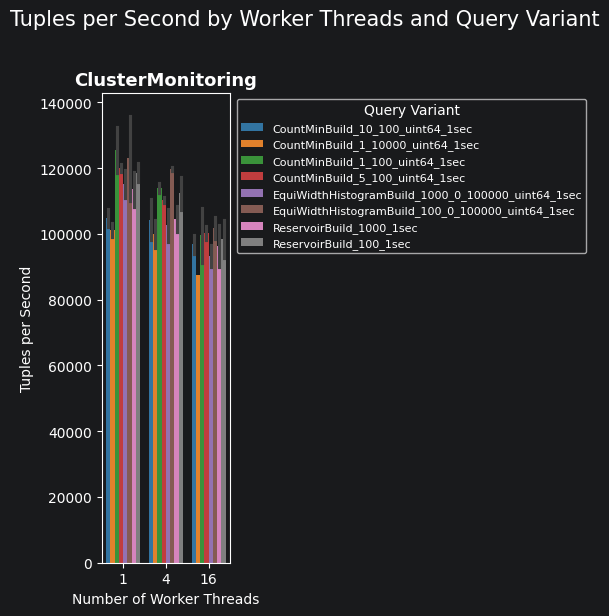

In [5]:
synopsis_types = df["synopsis_type"].unique()
n = len(synopsis_types)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), sharey=True)

# Ensure axes is always iterable
if n == 1:
    axes = [axes]

for ax, synopsis in zip(axes, synopsis_types):
    subset = df[df["synopsis_type"] == synopsis]
    hue_order = sorted(subset["query_variant"].dropna().unique())
    palette = sns.color_palette("tab10", len(hue_order))

    sns.barplot(
        data=subset,
        x="numberOfWorkerThreads",
        y="tuplesPerSecond",
        hue="query_variant",
        hue_order=hue_order,
        palette=palette,
        ax=ax,
        errorbar="sd",       # show standard deviation as error bars; use None to disable
    )

    ax.set_title(synopsis, fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Worker Threads")
    ax.set_ylabel("Tuples per Second" if ax == axes[0] else "")
    ax.legend(title="Query Variant", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

fig.suptitle("Tuples per Second by Worker Threads and Query Variant", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

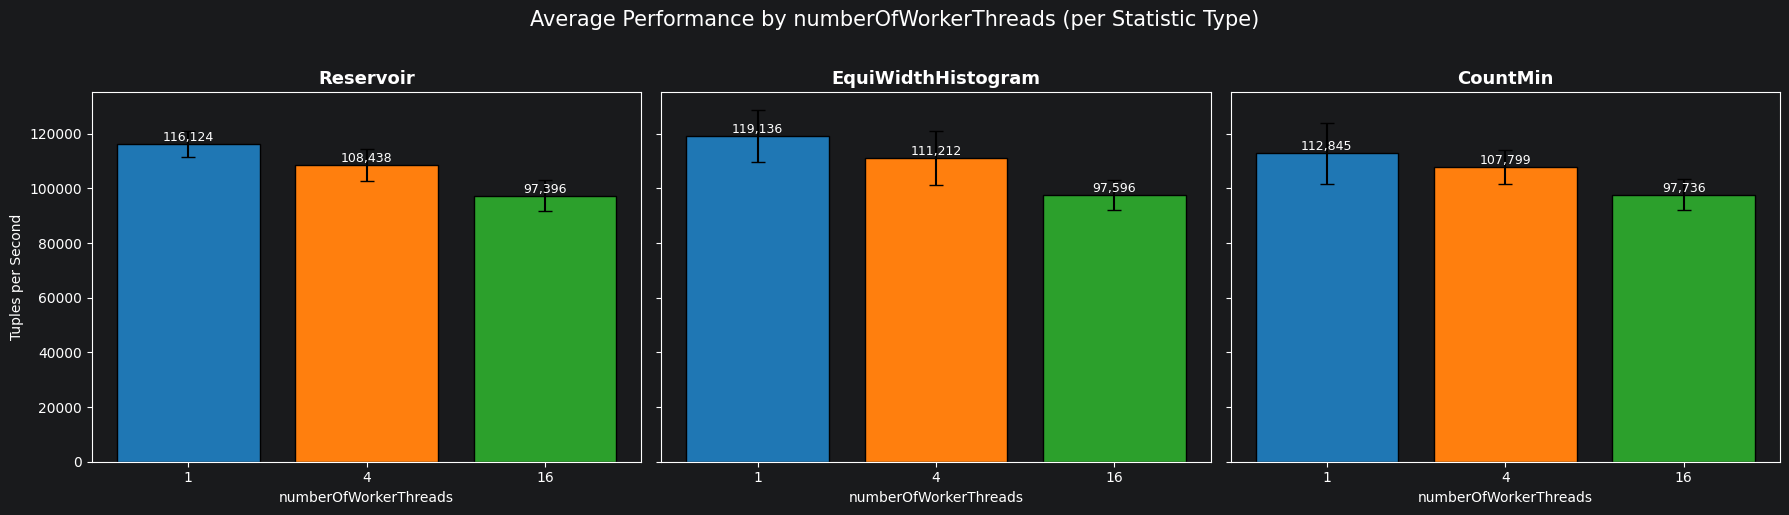

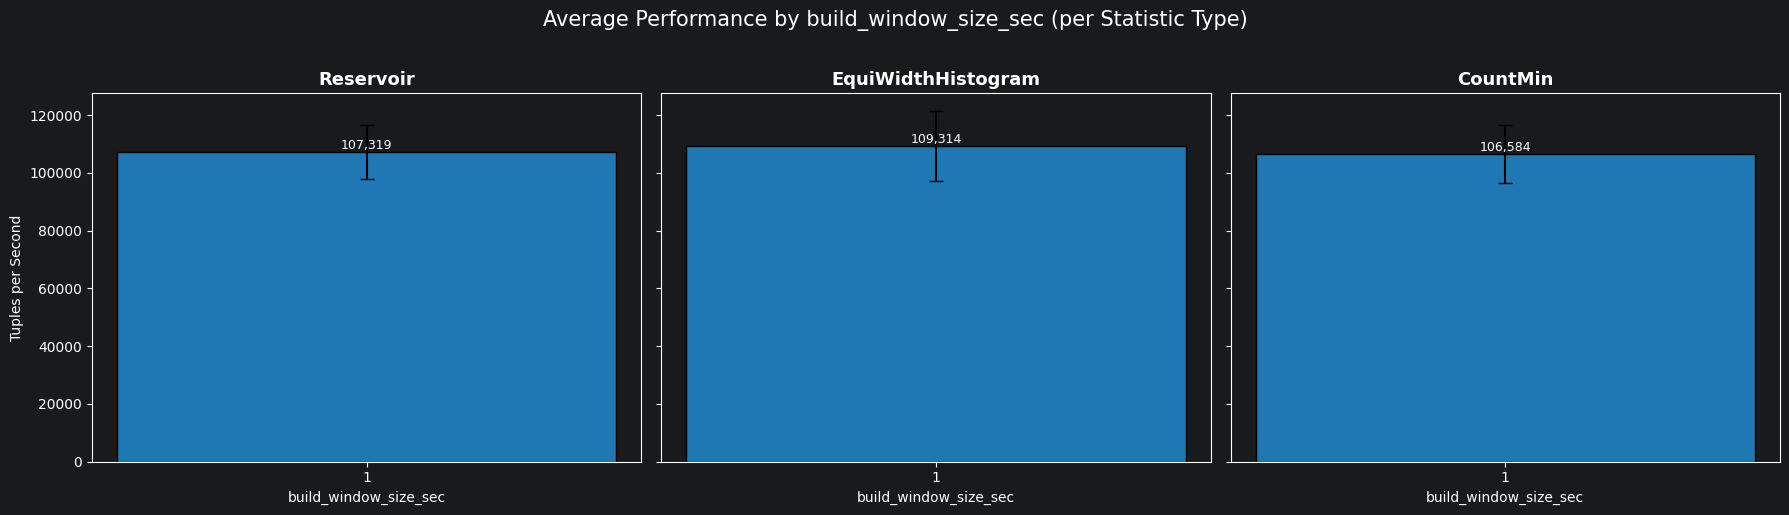

In [6]:
def plot_avg_performance_by(df, param):
    """Bar chart of avg tuples/sec per statistic type, grouped by `param`."""
    statistic_types = df["statistic_type"].unique()
    n = len(statistic_types)

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, stat_type in zip(axes, statistic_types):
        subset = df[df["statistic_type"] == stat_type]
        avg = subset.groupby(param)["tuplesPerSecond"].agg(["mean", "std"]).reset_index()
        avg = avg.sort_values(param)

        bars = ax.bar(
            avg[param].astype(str),
            avg["mean"],
            yerr=avg["std"],
            capsize=5,
            color=sns.color_palette("tab10", len(avg)),
            edgecolor="black",
        )

        ax.set_xlabel(param)
        ax.set_ylabel("Tuples per Second" if ax == axes[0] else "")
        ax.set_title(f"{stat_type}", fontsize=13, fontweight="bold")

        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:,.0f}",
                    ha="center", va="bottom", fontsize=9)

    fig.suptitle(f"Average Performance by {param} (per Statistic Type)", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

plot_avg_performance_by(df, "numberOfWorkerThreads")
plot_avg_performance_by(df, "build_window_size_sec")